# Лабораторная работа: Генеративные модели классификации (LDA и Naive Bayes)

## Общая цель работы
Изучить генеративный подход к классификации на примере двух моделей: **Линейный дискриминантный анализ (LDA)** и **Наивный байесовский классификатор (NB)**. Вы не просто реализуете алгоритмы, а исследуете, как предположения о структуре данных (ковариация, независимость признаков) влияют на разделяющую поверхность и качество классификации.

---

## Теоретическое введение (обязательно к прочтению)

### Генеративный vs дискриминативный подход
- **Дискриминативные модели** (логистическая регрессия, SVM) моделируют границу между классами напрямую: $ p(y|x) $.
- **Генеративные модели** моделируют совместное распределение $ p(x, y) = p(x|y) \cdot p(y) $, а затем через теорему Байеса получают $ p(y|x) $.

### Байесовский классификатор
Для задачи классификации с $ K $ классами:
$
\hat{y} = \arg\max_{y} p(y|x) = \arg\max_{y} \frac{p(x|y) \cdot p(y)}{p(x)} = \arg\max_{y} p(x|y) \cdot p(y)
$

Где:
- $ p(y) $ — **априорная вероятность** класса (оценивается как доля объектов класса в выборке).
- $ p(x|y) $ — **правдоподобие** (likelihood) — вероятность наблюдать объект $ x $ в классе $ y $.

### Два подхода к моделированию правдоподобия

**1. LDA (Линейный дискриминантный анализ)**
- Предполагает, что $ p(x|y) $ — многомерное нормальное распределение.
- **Ключевое допущение:** матрицы ковариации для всех классов **одинаковы**: $ C_0 = C_1 = ... = C $.
- **Следствие:** разделяющая поверхность между классами является **линейной** (гиперплоскостью).
- Параметры для каждого класса: $ \mu_y $ (среднее) и общая $ C $.

**2. Наивный байесовский классификатор (NB)**
- Также предполагает нормальное распределение $ p(x|y) $, но **без учета корреляций** между признаками.
- **Ключевое допущение:** признаки условно независимы при заданном классе:
  $
  p(x_1, x_2, ..., x_n|y) = \prod_{i=1}^{n} p(x_i|y)
  $
- **Следствие:** матрица ковариации для каждого класса **диагональная** (все внедиагональные элементы = 0).
- Параметры для каждого класса: $ \mu_y $ и $ \sigma_{y,i}^2 $ (дисперсия каждого признака отдельно).

**Важно:** LDA и NB — частные случаи одного и того же байесовского подхода, различающиеся структурой ковариационной матрицы:
- LDA: одна полная матрица ковариации $ C $ для всех классов.
- NB: отдельная диагональная матрица для каждого класса.

---

## Часть 1. Исследование многомерного нормального распределения (10 баллов)

### 1.1 Генерация данных с заданной ковариацией
**Цель:** научиться генерировать данные с контролируемой структурой зависимости.

1. Создайте $ M = 500 $ точек в двумерном пространстве:
   - Сгенерируйте два независимых вектора: $ x_1 \sim \mathcal{N}(0, \sigma_1^2) $, $ x_2 \sim \mathcal{N}(0, \sigma_2^2) $, где $ \sigma_1 = 0.3 $, $ \sigma_2 = 0.8 $.
2. Примените матрицу поворота на угол $ \alpha = 30^\circ $:
   $
   R = \begin{bmatrix} \cos\alpha & -\sin\alpha \\ \sin\alpha & \cos\alpha \end{bmatrix}
   $
3. Выведите на экран **выборочную матрицу ковариации** (через `np.cov`).
4. Сравните с теоретической: $ C_{теор} = R \cdot \text{diag}(\sigma_1^2, \sigma_2^2) \cdot R^T $.

**Визуализация:**
- Постройте scatter plot полученных точек.
- На том же графике (используя `plt.contour`) нарисуйте эллипсы равной плотности для теоретического распределения (на уровнях 0.5, 1, 2 стандартных отклонения).

**Автопроверка:**
```python
# Проверка: размерность и наличие поворота
assert X.shape == (M, 2), "Неверная размерность данных"
assert np.abs(np.cov(X.T)[0, 1]) > 0.1, "Корреляция слишком мала (проверьте поворот)"
assert np.allclose(np.mean(X, axis=0), 0, atol=0.1), "Среднее должно быть около 0"
```

### 1.2 Сравнение с встроенной функцией
- Сгенерируйте точки с помощью `np.random.multivariate_normal` с той же матрицей ковариации.
- Нарисуйте оба облака точек на одном графике разными цветами.
- **Вопрос (ответить текстом в Markdown):** совпадают ли облака визуально? Почему встроенная функция может быть предпочтительнее?

---

## Часть 2. Визуализация плотности вероятности (5 баллов)

**Цель:** научиться вычислять и визуализировать PDF многомерного нормального распределения.

1. По данным из пункта 1.1 оцените $ \hat{\mu} $ и $ \hat{C} $ (выборочные).
2. Создайте сетку точек в диапазоне от -2 до 2 по обеим осям.
3. Вычислите плотность вероятности в каждой точке сетки **двумя способами**:
   - С помощью `scipy.stats.multivariate_normal(mean=mu, cov=C).pdf()`.
   - Самостоятельно по формуле (1) из задания (используйте `np.linalg.det` и `np.linalg.inv`).
4. Сравните результаты (максимальная разница должна быть < 1e-10).

**Визуализация:**
- Постройте contour plot с заливкой (используя `plt.contourf`).
- Добавьте линии уровня (contour) с подписями значений.
- Нанесите исходные точки поверх фона.

**Автопроверка:**
```python
# Проверка ручного вычисления
pdf_manual = ... # ваша реализация
pdf_scipy = m.pdf(grid_points)
assert np.allclose(pdf_manual, pdf_scipy, atol=1e-8), "Ручное вычисление отличается от scipy"
```

---

## Часть 3. Бинарная классификация через байесовский подход (15 баллов)

**Цель:** визуализировать разделяющую поверхность для двух классов.

### 3.1 Генерация датасета
Создайте два класса (по 300 точек каждый):
- **Класс 0:** $ \mu_0 = (-0.5, 0.5) $, $ C_0 = \begin{bmatrix} 0.2 & 0.1 \\ 0.1 & 0.3 \end{bmatrix} $
- **Класс 1:** $ \mu_1 = (0.5, -0.5) $, $ C_1 = \begin{bmatrix} 0.3 & -0.1 \\ -0.1 & 0.2 \end{bmatrix} $

### 3.2 Визуализация апостериорной вероятности
Для каждой точки сетки вычислите:
$
\Delta(x) = p(x|y=0) \cdot p(y=0) - p(x|y=1) \cdot p(y=1)
$
где $ p(y) $ оценивается как доля объектов класса в выборке.

**Визуализация:**
- Scatter plot точек классов (разными цветами).
- Заливка фона: положительные значения $ \Delta $ — одним цветом (например, синим), отрицательные — другим (красным).
- Линия, где $ \Delta(x) = 0 $ (разделяющая поверхность) — через `plt.contour(..., levels=[0])`.

**Вопрос (ответить текстом):** является ли разделяющая поверхность линейной? Почему?

---

## Часть 4. Линейный дискриминантный анализ (LDA) (20 баллов)

### 4.1 Теоретический вывод (в тетради)
**Задание:** выведите явное выражение для разделяющей поверхности в случае, когда $ C_0 = C_1 = C $. Покажите, что она линейна. Напишите формулу для весов $ w $ и порога $ b $ в уравнении $ w^T x + b = 0 $.

### 4.2 Реализация класса LDA
Реализуйте класс `MyLDA`, следуя шаблону:

```python
from sklearn.base import BaseEstimator
import numpy as np

class MyLDA(BaseEstimator):
    def __init__(self):
        self.classes_ = None
        self.means_ = None      # словарь {class: mean_vector}
        self.priors_ = None     # словарь {class: prior_prob}
        self.cov_ = None        # общая ковариационная матрица (2D массив)
        self.coef_ = None       # вектор весов w
        self.intercept_ = None  # порог b
    
    def fit(self, X, y):
        """
        X: np.array, shape (n_samples, n_features)
        y: np.array, shape (n_samples,)
        """
        # 1. Сохранить уникальные классы
        # 2. Для каждого класса: вычислить mean и prior
        # 3. Вычислить общую ковариационную матрицу (усредненную по классам)
        # 4. Вычислить w и b
        pass
    
    def predict(self, X):
        """Возвращает предсказанные классы для X"""
        pass
    
    def predict_proba(self, X):
        """Возвращает вероятности принадлежности к каждому классу"""
        pass
```

**Указания:**
- Для устойчивости добавьте небольшой регуляризатор к ковариационной матрице: `cov_reg = cov + 1e-6 * np.eye(n_features)`.
- Формула для весов для бинарного случая:
  $
  w = C^{-1} (\mu_1 - \mu_0)
  $
  $
  b = -\frac{1}{2} \mu_0^T C^{-1} \mu_0 + \frac{1}{2} \mu_1^T C^{-1} \mu_1 + \log\frac{p(y=1)}{p(y=0)}
  $

### 4.3 Проверка на синтетике
- Создайте два класса с одинаковой ковариацией $ C = \begin{bmatrix} 1 & 0.5 \\ 0.5 & 1 \end{bmatrix} $, но разными средними.
- Обучите ваш `MyLDA` и сравните предсказания с `sklearn.discriminant_analysis.LinearDiscriminantAnalysis`.
- Визуализируйте разделяющую прямую и точки.

**Автопроверка:**
```python
# Сравнение с sklearn
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
sk_lda = LinearDiscriminantAnalysis().fit(X_train, y_train)
my_lda = MyLDA().fit(X_train, y_train)
assert np.allclose(my_lda.predict(X_test), sk_lda.predict(X_test)), "Предсказания не совпадают"
assert np.abs(my_lda.coef_ @ sk_lda.coef_ - 1) < 1e-6, "Вектора весов сонаправлены, но разной длины"
```

---

## Часть 5. Наивный байесовский классификатор (NB) (20 баллов)

### 5.1 Теоретическое обоснование
**Вопрос:** почему в наивном байесе матрица ковариации диагональная? Как это упрощает вычисление $ p(x|y) $?

### 5.2 Реализация класса NB
Реализуйте класс `MyNB`:

```python
class MyNB(BaseEstimator):
    def __init__(self):
        self.classes_ = None
        self.means_ = None      # dict {class: mean_vector}
        self.vars_ = None       # dict {class: variance_vector} (диагональ ковариации)
        self.priors_ = None     # dict {class: prior_prob}
    
    def fit(self, X, y):
        """
        Для каждого класса:
        - Вычислить среднее по каждому признаку
        - Вычислить дисперсию по каждому признаку
        - Вычислить априорную вероятность
        """
        pass
    
    def predict(self, X):
        """Вычисляет логарифм правдоподобия для каждого класса и выбирает максимум"""
        pass
```

**Важно:** используйте **логарифмическое правдоподобие** для численной устойчивости:
$
\log p(y|x) \propto \log p(y) + \sum_i \log p(x_i|y) = \log p(y) - \frac{1}{2}\sum_i \left( \log(2\pi\sigma_{y,i}^2) + \frac{(x_i - \mu_{y,i})^2}{\sigma_{y,i}^2} \right)
$

### 5.3 Сравнение с sklearn
- Сравните ваш `MyNB` с `sklearn.naive_bayes.GaussianNB` на тех же данных.
- Убедитесь, что предсказания совпадают (с точностью до численных погрешностей).

**Автопроверка:**
```python
from sklearn.naive_bayes import GaussianNB
sk_nb = GaussianNB().fit(X_train, y_train)
my_nb = MyNB().fit(X_train, y_train)
assert np.allclose(my_nb.predict(X_test), sk_nb.predict(X_test)), "Предсказания NB не совпадают"
```

---

## Часть 6. Экспериментальное сравнение LDA и NB (15 баллов)

### 6.1 Генерация датасетов с разной структурой
Создайте **три** различных датасета для бинарной классификации:

1. **Датасет A (LDA-оптимальный):** классы имеют одинаковую ковариацию, но разные средние.
2. **Датасет B (NB-оптимальный):** признаки независимы внутри каждого класса, но ковариации классов разные.
3. **Датасет C (сложный):** признаки коррелированы, ковариации классов разные.

Используйте `sklearn.datasets.make_classification` с параметрами:
- `n_features=10` (для проверки многомерности)
- `n_informative=5`, `n_redundant=2`
- Для датасета C: `flip_y=0.05` (немного шума).

### 6.2 Сравнение моделей
Для каждого датасета:
1. Разделите на train/test (80/20).
2. Обучите `MyLDA`, `MyNB`, а также (для бенчмарка) `sklearn.linear_model.LogisticRegression`.
3. Посчитайте метрики: **Accuracy**, **Precision**, **Recall**, **F1-score** (для каждого класса отдельно и macro-усредненные).
4. Постройте confusion matrix для каждой модели.

### 6.3 Анализ результатов
В Markdown-ячейке напишите **развернутый вывод**:
- На каком датасете LDA превосходит NB? Почему?
- На каком датасете NB работает лучше? Почему?
- Как влияет размерность пространства на обе модели?
- Когда обе модели падают (датасет C) — почему?

**Визуализация:** для каждого датасета постройте столбчатую диаграмму сравнения метрик.

---

## Критерии оценки (максимум 85 баллов)

| Часть | Баллы | Что проверяется |
|-------|-------|-----------------|
| 1.1 Генерация и поворот | 5 | Корректная генерация, визуализация, сравнение ковариаций |
| 1.2 Сравнение с `multivariate_normal` | 5 | Понимание способов генерации |
| 2. PDF и визуализация | 5 | Ручное вычисление, сравнение со scipy |
| 3. Бинарная классификация | 10 | Правильная визуализация Δ и разделяющей поверхности |
| 4.1 Теоретический вывод LDA | 5 | Формулы для w и b |
| 4.2 Реализация MyLDA | 10 | Код, совместимость со sklearn API |
| 4.3 Проверка на синтетике | 5 | Сравнение с sklearn, визуализация |
| 5.1 Теория NB | 5 | Понимание условной независимости |
| 5.2 Реализация MyNB | 10 | Код, логарифмическое правдоподобие |
| 5.3 Проверка с sklearn | 5 | Совпадение предсказаний |
| 6.1 Генерация 3 датасетов | 5 | Разнообразие структур |
| 6.2 Эксперименты и метрики | 10 | Все метрики, confusion matrix |
| 6.3 Анализ и выводы | 10 | Глубокий анализ результатов |
| **Стиль кода и оформление** | **Бонус +5** | Чистый код, комментарии, структура ноутбука |

---

## Полезные функции и материалы

### Генерация датасета с заданной ковариацией
```python
def generate_gaussian_class(mean, cov, n_samples=300):
    return np.random.multivariate_normal(mean, cov, n_samples)

# Пример создания двух классов
X0 = generate_gaussian_class(mean0, cov0, 300)
X1 = generate_gaussian_class(mean1, cov1, 300)
X = np.vstack([X0, X1])
y = np.hstack([np.zeros(300), np.ones(300)])
```

### Вычисление разделяющей поверхности
```python
def decision_function(X, means, cov, priors):
    """Возвращает разность логарифмов апостериорных вероятностей"""
    log_p0 = np.log(priors[0]) + multivariate_normal(means[0], cov).logpdf(X)
    log_p1 = np.log(priors[1]) + multivariate_normal(means[1], cov).logpdf(X)
    return log_p1 - log_p0  # >0 => класс 1, <0 => класс 0
```

---

## Рекомендации по оформлению

1. Каждая часть должна быть отдельным разделом с заголовком.
2. Код должен быть прокомментирован (на русском или английском).
3. Все графики должны иметь подписи осей и легенды.
4. В конце каждой части — краткий вывод (1-2 предложения).
5. Итоговый вывод — развернутый (10+ предложений) с ответами на все поставленные вопросы.

---

Это задание теперь требует не только написания кода, но и **понимания теории** через визуализацию и эксперименты. Все блоки с проверками помогут студентам самостоятельно убедиться в корректности решения, а преподавателю — быстро оценить работу.

Выборочная ковариация (ручной поворот):
 [[ 0.20333259 -0.22019019]
 [-0.22019019  0.46396289]]
Выборочная ковариация (встроенная):
 [[ 0.20597574 -0.22756401]
 [-0.22756401  0.50624872]]
Теоретическая ковариация:
 [[ 0.2275     -0.23815699]
 [-0.23815699  0.5025    ]]


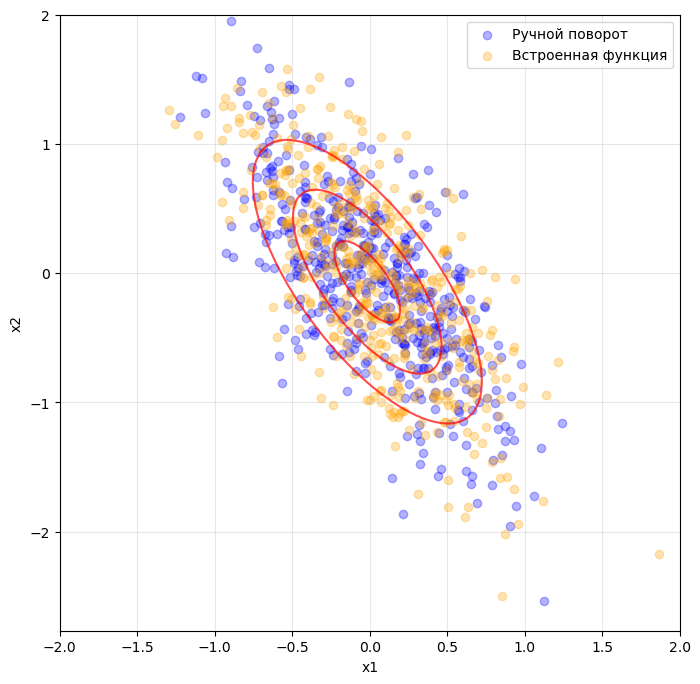

In [84]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import multivariate_normal
%matplotlib inline

M = 500
sigma1 = 0.3
sigma2 = 0.8
x1 = np.random.normal(0, sigma1, size=M)
x2 = np.random.normal(0, sigma2, size=M)
X = np.column_stack((x1, x2)) #concentrate
theta = np.radians(30)
c, s = np.cos(theta), np.sin(theta)
R = np.array(((c, -s), (s, c)))
X_rot = X @ R.T

C_cov_rot = np.cov(X_rot.T) 
D = np.array([[sigma1**2, 0], [0, sigma2**2]])
C_t = R @ D @ R.T

X_builtin = np.random.multivariate_normal(mean=[0, 0], cov=C_t, size=M)
C_cov_builtin = np.cov(X_builtin.T)


print("Выборочная ковариация (ручной поворот):\n", C_cov_rot)
print("Выборочная ковариация (встроенная):\n", C_cov_builtin)
print("Теоретическая ковариация:\n", C_t)


assert X_rot.shape == (M, 2), "Неверная размерность данных"
assert np.abs(np.cov(X_rot.T)[0, 1]) > 0.1, "Корреляция слишком мала (проверьте поворот)"
assert np.allclose(np.mean(X_rot, axis=0), 0, atol=0.1), "Среднее должно быть около 0"


plt.figure(figsize=(8, 8))
plt.scatter(X_rot[:, 0], X_rot[:, 1], alpha=0.3, color='blue', label='Ручной поворот')
plt.scatter(X_builtin[:, 0], X_builtin[:, 1], alpha=0.3, color='orange', label='Встроенная функция')
x_grid, y_grid = np.mgrid[-2:2:100j, -2:2:100j]
pos = np.dstack((x_grid, y_grid))
mean = np.mean(X, axis=0)
density = multivariate_normal(mean, C_t).pdf(pos)
plt.contour(x_grid, y_grid, density, levels=3, alpha=0.7, colors='red', linewidths=1.5)
plt.xlabel('x1')
plt.ylabel('x2')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

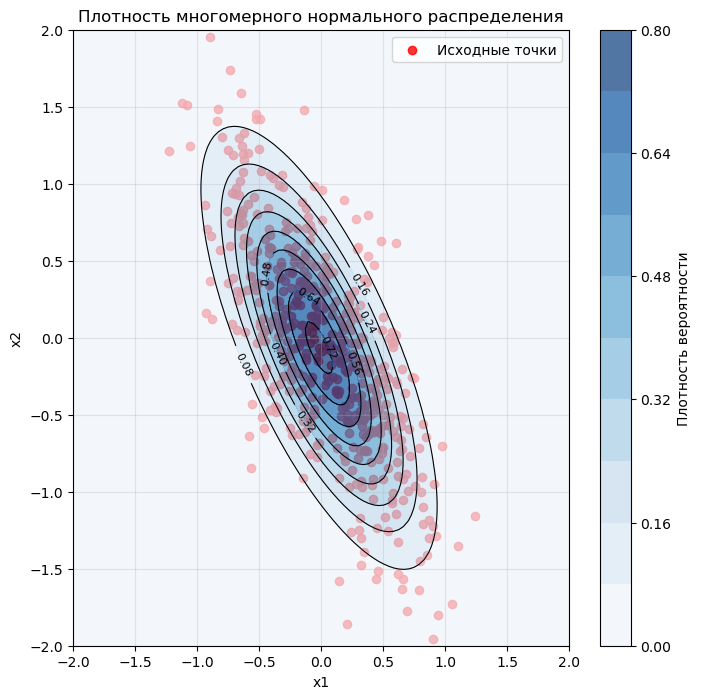

In [86]:
x_grid, y_grid = np.mgrid[-2:2:100j, -2:2:100j]
pos = np.dstack((x_grid, y_grid))
mean = np.mean(X, axis=0)
dev = pos - mean
mu_sr = np.mean(X, axis=0)
P1 = multivariate_normal(mean=mu_sr, cov=C_cov_rot).pdf(pos)
P2 = (1.0 / (2 * np.pi * np.sqrt(np.linalg.det(C_cov_rot)))) * np.exp(-0.5 * np.sum(dev @ np.linalg.inv(C_cov_rot) * dev, axis=-1))

assert np.allclose(P2, P1, atol=1e-8), "Ручное вычисление отличается от scipy"

plt.figure(figsize=(8, 8))
plt.scatter(X_rot[:, 0], X_rot[:, 1], alpha=0.8, color='red', label='Исходные точки')
cf = plt.contourf(x_grid, y_grid, P1, levels=10, cmap='Blues', alpha=0.7)
plt.colorbar(cf, label='Плотность вероятности')
cs = plt.contour(x_grid, y_grid, P1, levels=10, colors='black', linewidths=0.8)
plt.clabel(cs, inline=True, fontsize=8)
plt.xlim(-2, 2)
plt.ylim(-2, 2)
plt.xlabel('x1')
plt.ylabel('x2')
plt.grid(True, alpha=0.3)
plt.title('Плотность многомерного нормального распределения')
plt.legend()
plt.show()


In [22]:
переписать мю и матрицы, а потом с normal ка в начале создать 2 икса с туда просто C китнуть 

SyntaxError: invalid syntax (510431860.py, line 1)

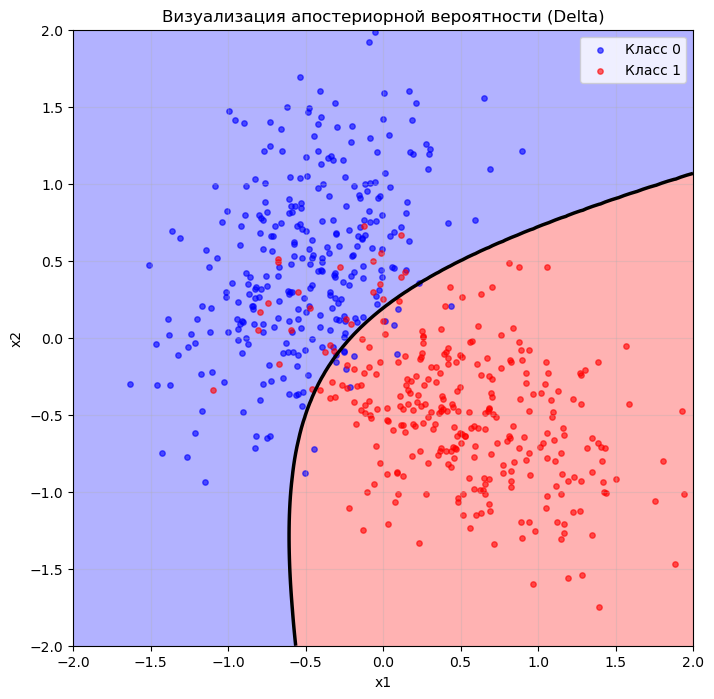

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import multivariate_normal

M = 300

mu0 = np.array([-0.5, 0.5])
cov0 = np.array([[0.2, 0.1], [0.1, 0.3]])
mu1 = np.array([0.5, -0.5])
cov1 = np.array([[0.3, -0.1], [-0.1, 0.2]])

X0 = np.random.multivariate_normal(mu0, cov0, size=M)
X1 = np.random.multivariate_normal(mu1, cov1, size=M)
X = np.vstack([X0, X1])
y = np.hstack([np.zeros(M), np.ones(M)])

# Априорные вероятности 
prior0 = np.sum(y == 0) / len(y)  # = 0.5
prior1 = np.sum(y == 1) / len(y)  # = 0.5

likelihood0 = multivariate_normal(mean=mu0, cov=cov0).pdf(pos)
likelihood1 = multivariate_normal(mean=mu1, cov=cov1).pdf(pos)

# Delta(x) = p(x|y=0)*p(y=0) - p(x|y=1)*p(y=1)
delta = (likelihood0 * prior0) - (likelihood1 * prior1)

plt.figure(figsize=(8, 8))
x_grid, y_grid = np.mgrid[-2:2:100j, -2:2:100j]
pos = np.dstack((x_grid, y_grid))
plt.contourf(x_grid, y_grid, delta, levels=[-1, 0, 1], colors=['red', 'blue'], alpha=0.3)
plt.contour(x_grid, y_grid, delta, levels=[0], colors='black', linewidths=2.5, linestyles='solid')
plt.scatter(X0[:, 0], X0[:, 1], alpha=0.6, color='blue', s=15, label='Класс 0')
plt.scatter(X1[:, 0], X1[:, 1], alpha=0.6, color='red', s=15, label='Класс 1')
plt.xlim(-2, 2)
plt.ylim(-2, 2)
plt.xlabel('x1')
plt.ylabel('x2')
plt.title('Визуализация апостериорной вероятности (Delta)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [52]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.base import BaseEstimator
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
import numpy as np

class MyLDA(BaseEstimator):
    def __init__(self):
        self.classes_ = None
        self.means_ = None      # словарь {class: mean_vector}
        self.priors_ = None     # словарь {class: prior_prob}
        self.cov_ = None        # общая ковариационная матрица (2D массив)
        self.coef_ = None       # вектор весов w
        self.intercept_ = None  # порог b
    

    def fit(self, X, y):
        n_samples, n_features = X.shape
        
        # 1. Сохранить уникальные классы
        self.classes_ = np.unique(y)
        
        # 2. Для каждого класса: вычислить mean и prior
        self.means_ = {}
        self.priors_ = {}
        for c in self.classes_:
            X_c = X[y == c]
            self.means_[c] = np.mean(X_c, axis=0)
            self.priors_[c] = X_c.shape[0] / n_samples
            
        # 3. Вычислить общую ковариационную матрицу (усредненную по классам)
        cov = np.zeros((n_features, n_features))
        for c in self.classes_:
            X_c = X[y == c]
            X_centered = X_c - self.means_[c]
            cov += X_centered.T @ X_centered
        cov /= n_samples
        self.cov_ = cov + 1e-6 * np.eye(n_features)

        inv_cov = np.linalg.inv(self.cov_)
        c0, c1 = self.classes_[0], self.classes_[1]
        mu0 = self.means_[c0]
        mu1 = self.means_[c1]

        diff_mean = (mu1 - mu0).reshape(-1, 1)          
        w = inv_cov @ diff_mean                     
        self.coef_ = w.ravel()                        

        self.intercept_ = -0.5 * mu1.T @ inv_cov @ mu1 + 0.5 * mu0.T @ inv_cov @ mu0 + np.log(self.priors_[c1] / self.priors_[c0])

        return self

    
    def predict(self, X):
        """Возвращает предсказанные классы для X"""
        scores = X @ self.coef_ + self.intercept_
        c0, c1 = self.classes_[0], self.classes_[1]
        preds = np.where(scores >= 0, c1, c0)
        return preds
    
    def predict_proba(self, X):
        n_samples = X.shape[0]
        cov_inv = np.linalg.inv(self.cov_)
        proba = np.zeros((n_samples, 2))
        
        for i, c in enumerate(self.classes_):
            proba[:, i] = np.exp(-0.5 * np.sum((X - self.means_[c]) @ cov_inv * (X - self.means_[c]), axis=1)) * self.priors_[c]
        proba /= proba.sum(axis=1, keepdims=True)
        return proba  

Совпадение предсказаний MyLDA и sklearn LDA: 100.00%


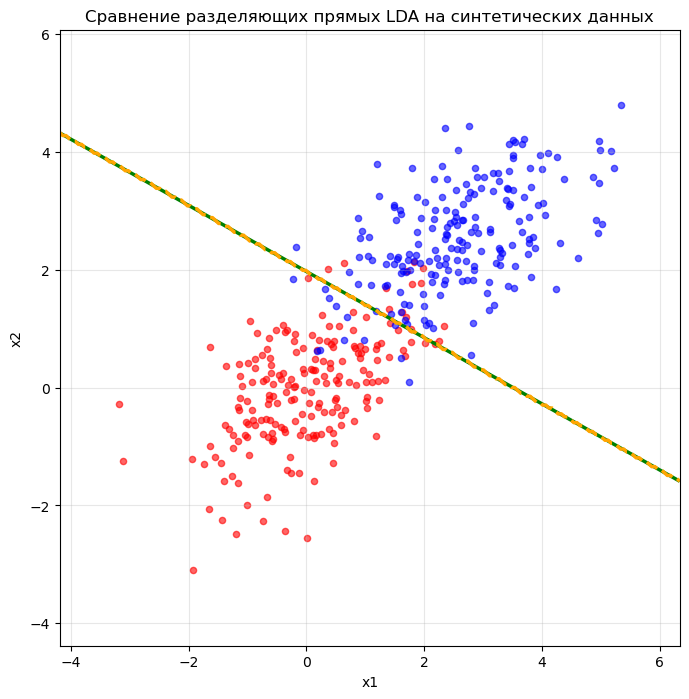

In [53]:
C = np.array([[1, 0.5], [0.5, 1]])
mu0 = np.array([0, 0])
mu1 = np.array([2.5, 2.5])
n = 200

rng = np.random.default_rng(42)
X0 = rng.multivariate_normal(mu0, C, n)
X1 = rng.multivariate_normal(mu1, C, n)
X = np.vstack([X0, X1])
y = np.hstack([np.zeros(n), np.ones(n)])

my_lda = MyLDA().fit(X, y)
sk_lda = LinearDiscriminantAnalysis(solver='lsqr', store_covariance=True).fit(X, y)
preds_my = my_lda.predict(X)  
preds_sk = sk_lda.predict(X)

match = np.mean(preds_my == preds_sk) * 100
print(f"Совпадение предсказаний MyLDA и sklearn LDA: {match:.2f}%")

plt.figure(figsize=(8, 8))
plt.scatter(X0[:, 0], X0[:, 1], c='red', label='Класс 0', alpha=0.6, s=20)
plt.scatter(X1[:, 0], X1[:, 1], c='blue', label='Класс 1', alpha=0.6, s=20)

x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200), np.linspace(y_min, y_max, 200))
grid_points = np.c_[xx.ravel(), yy.ravel()]

scores_my = grid_points @ my_lda.coef_ + my_lda.intercept_
Z_my = scores_my.reshape(xx.shape)
plt.contour(xx, yy, Z_my, levels=[0], colors='green', linewidths=2.5, linestyles='-')

Z_sk = sk_lda.predict(grid_points).reshape(xx.shape)
plt.contour(xx, yy, Z_sk, levels=[0.5], colors='orange', linewidths=2.5, linestyles='--')

plt.plot([], [], color='green', label='Разделяющая прямая MyLDA')
plt.plot([], [], color='orange', linestyle='--', label='Разделяющая прямая sklearn LDA')

plt.xlabel('x1')
plt.ylabel('x2')
plt.title('Сравнение разделяющих прямых LDA на синтетических данных')
plt.grid(True, alpha=0.3)
plt.axis('equal')
plt.show()



In [56]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
sk_lda = LinearDiscriminantAnalysis().fit(X_train, y_train)
my_lda = MyLDA().fit(X_train, y_train)
assert np.allclose(my_lda.predict(X_test), sk_lda.predict(X_test)), "Предсказания не совпадают"
w_my = my_lda.coef_                                 # (2,)
w_sk = sk_lda.coef_.ravel()                         # (2,)
cos_angle = (w_my @ w_sk) / (np.linalg.norm(w_my) * np.linalg.norm(w_sk))
assert np.abs(cos_angle - 1.0) < 1e-6, "Векторы весов должны быть сонаправлены"

In [70]:
import numpy as np
from sklearn.base import BaseEstimator

class MyNB(BaseEstimator):
    def __init__(self):
        self.classes_ = None
        self.means_ = {}   # dict {class: mean_vector}
        self.vars_ = {}    # dict {class: variance_vector}
        self.priors_ = {}  # dict {class: prior_prob}

    def fit(self, X, y):
        X = np.array(X)
        y = np.array(y)
        self.classes_ = np.unique(y)
        n_samples = X.shape[0]

        for c in self.classes_:
            X_c = X[y == c]
            self.means_[c] = np.mean(X_c, axis=0)
            self.vars_[c] = np.var(X_c, axis=0) + 1e-9
            self.priors_[c] = X_c.shape[0] / n_samples

        return self

    def predict(self, X):
        X = np.array(X)
        log_posteriors = []

        for c in self.classes_:
            log_prior = np.log(self.priors_[c])

            mean = self.means_[c]
            variance = self.vars_[c]

            log_likelihood = -0.5 * np.sum(
                np.log(2 * np.pi * variance) + ((X - mean) ** 2) / variance,
                axis=1
            )

            log_posteriors.append(log_prior + log_likelihood)

        log_posteriors = np.array(log_posteriors)

        best_class_indices = np.argmax(log_posteriors, axis=0)

        return self.classes_[best_class_indices]

In [71]:
from sklearn.naive_bayes import GaussianNB
sk_nb = GaussianNB().fit(X_train, y_train)
my_nb = MyNB().fit(X_train, y_train)
assert np.allclose(my_nb.predict(X_test), sk_nb.predict(X_test)), "Предсказания NB не совпадают"


 Датасет A
MyLDA: acc=0.830 prec=0.827 rec=0.829 f1=0.828
  CM:
[[94 18]
 [16 72]]
MyNB: acc=0.890 prec=0.896 rec=0.882 f1=0.887
  CM:
[[106   6]
 [ 16  72]]
LogReg: acc=0.835 prec=0.832 rec=0.833 f1=0.833
  CM:
[[95 17]
 [16 72]]


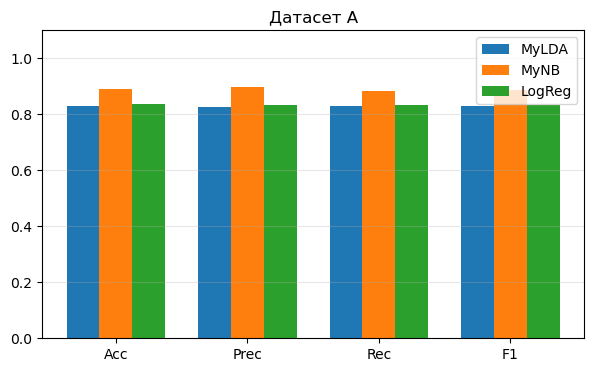


 Датасет B
MyLDA: acc=0.830 prec=0.827 rec=0.829 f1=0.828
  CM:
[[94 18]
 [16 72]]
MyNB: acc=0.890 prec=0.896 rec=0.882 f1=0.887
  CM:
[[106   6]
 [ 16  72]]
LogReg: acc=0.835 prec=0.832 rec=0.833 f1=0.833
  CM:
[[95 17]
 [16 72]]


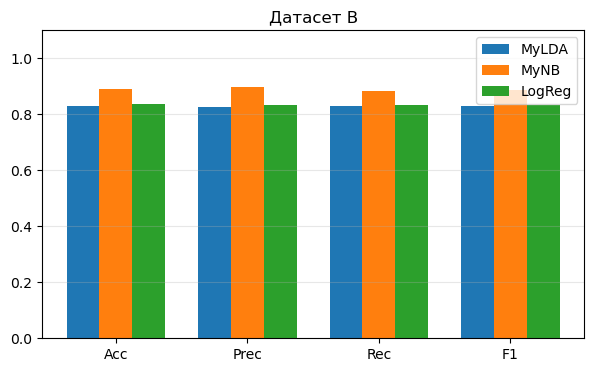


 Датасет C
MyLDA: acc=0.830 prec=0.827 rec=0.829 f1=0.828
  CM:
[[94 18]
 [16 72]]
MyNB: acc=0.890 prec=0.896 rec=0.882 f1=0.887
  CM:
[[106   6]
 [ 16  72]]
LogReg: acc=0.835 prec=0.832 rec=0.833 f1=0.833
  CM:
[[95 17]
 [16 72]]


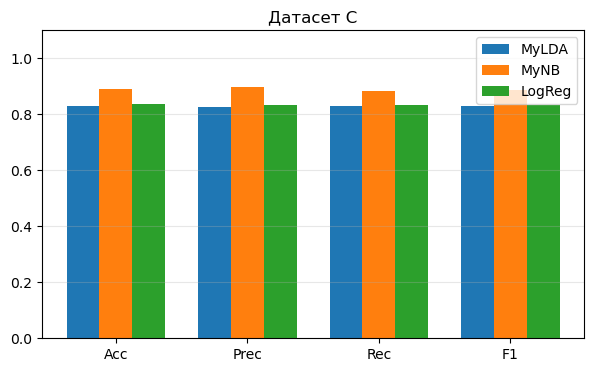

In [90]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix


X_A, y_A = make_classification(n_samples=1000, n_features=10, n_informative=5, n_redundant=2, random_state=42)

X_B, y_B = make_classification(n_samples=1000, n_features=10, n_informative=5, n_redundant=2, random_state=42)
X_B[y_B == 1] #*= 3.0

X_C, y_C = make_classification(n_samples=1000, n_features=10, n_informative=5, n_redundant=2, random_state=42)
X_C[y_C == 1] #*= 2.0

datasets = {'A': (X_A, y_A), 'B': (X_B, y_B), 'C': (X_C, y_C)}
models = {'MyLDA': MyLDA(), 'MyNB': MyNB(), 'LogReg': LogisticRegression(max_iter=1000)}


for name, (X, y) in datasets.items():
    X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.2, random_state=42)
    print(f"\n Датасет {name}")
    
    scores = {}
    for m_name, model in models.items():
        model.fit(X_tr, y_tr)
        pred = model.predict(X_te)
        
        acc = accuracy_score(y_te, pred)
        prec = precision_score(y_te, pred, average='macro')
        rec = recall_score(y_te, pred, average='macro')
        f1 = f1_score(y_te, pred, average='macro')
        scores[m_name] = [acc, prec, rec, f1]
        
        print(f"{m_name}: acc={acc:.3f} prec={prec:.3f} rec={rec:.3f} f1={f1:.3f}")
        print(f"  CM:\n{confusion_matrix(y_te, pred)}")
    

    labels = ['Acc', 'Prec', 'Rec', 'F1']
    x = np.arange(4)
    w = 0.25
    plt.figure(figsize=(7, 4))
    for i, (m_name, vals) in enumerate(scores.items()):
        plt.bar(x + i * w, vals, w, label=m_name)
    plt.xticks(x + w, labels)
    plt.title(f"Датасет {name}")
    plt.ylim(0, 1.1)
    plt.legend()
    plt.grid(axis='y', alpha=0.3)
    plt.show()
